# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from collections import Counter
import re
import json

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

C:\Users\User\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


**Data setup**

This cell makes sure the RealWaste images are available before Part 1 runs. If a working `RealWaste` folder is already next to the notebook (for example from the GitHub repo), it is used as is. If the folder is missing, or holds Git LFS pointer files instead of real images (which happens when a repo is cloned without `git lfs`), the original dataset is downloaded from the UCI Machine Learning Repository and extracted to `./RealWaste`.

All later cells use the relative path `RealWaste`, so the notebook runs the same way locally, in Colab or after cloning the repo.

In [2]:
# Data setup: use ./RealWaste if it holds real images, otherwise download it from UCI
import pathlib
import shutil
import urllib.request
import zipfile

REALWASTE_URL = "https://archive.ics.uci.edu/static/public/908/realwaste.zip"
DATA_DIR = pathlib.Path("RealWaste")
ZIP_PATH = pathlib.Path("realwaste.zip")

print("Notebook working folder:", os.getcwd())


def realwaste_is_valid(folder):
    """True if the folder has class sub-folders containing real (openable) JPG images."""
    if not folder.is_dir():
        return False
    sample = next(folder.glob("*/*.jpg"), None)
    if sample is None:
        return False
    try:
        with Image.open(sample) as img:
            img.verify()
        return True
    except Exception:
        return False  # e.g. a Git LFS pointer file instead of an image


def download_file(url, destination):
    """Download with a browser-like header and a simple progress display."""
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request) as response, open(destination, "wb") as out:
        total = int(response.headers.get("Content-Length", 0))
        done = 0
        while True:
            block = response.read(1024 * 1024)
            if not block:
                break
            out.write(block)
            done += len(block)
            if total:
                print(f"\r  {done / 1e6:.0f} of {total / 1e6:.0f} MB", end="")
    print()


if realwaste_is_valid(DATA_DIR):
    print(f"Using existing dataset at {DATA_DIR.resolve()}")
else:
    if DATA_DIR.exists():
        # Keep the broken copy instead of deleting it
        DATA_DIR.rename("RealWaste_invalid_copy")
        print("Existing RealWaste folder has no readable images; renamed to RealWaste_invalid_copy")

    # Remove a partial or corrupted download left by an earlier attempt
    if ZIP_PATH.exists() and not zipfile.is_zipfile(ZIP_PATH):
        ZIP_PATH.unlink()
        print("Removed an incomplete realwaste.zip from a previous attempt")

    if not ZIP_PATH.exists():
        print("Downloading RealWaste from UCI...")
        download_file(REALWASTE_URL, ZIP_PATH)

    if not zipfile.is_zipfile(ZIP_PATH):
        raise RuntimeError(
            "The download did not produce a valid zip file. Download it in your browser from\n"
            f"{REALWASTE_URL}\nsave it as 'realwaste.zip' in {os.getcwd()} and run this cell again."
        )

    extract_dir = pathlib.Path("realwaste_extracted")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(extract_dir)

    # Some archives contain a nested zip; extract any we find
    for inner_zip in extract_dir.rglob("*.zip"):
        with zipfile.ZipFile(inner_zip) as zf:
            zf.extractall(inner_zip.parent)

    # Locate the folder that holds the 9 class folders
    candidates = [p for p in extract_dir.rglob("*")
                  if p.is_dir() and (p / "Cardboard").is_dir() and (p / "Plastic").is_dir()]
    if not candidates:
        raise FileNotFoundError("Could not find the RealWaste class folders inside the downloaded archive.")
    shutil.move(str(candidates[0]), str(DATA_DIR))
    print(f"Dataset ready at {DATA_DIR.resolve()}")

print("Class folders:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))


Notebook working folder: C:\Users\User\Desktop\Moringa Projects
Using existing dataset at C:\Users\User\Desktop\Moringa Projects\RealWaste
Class folders: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


Number of waste categories: 9

Waste categories:
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation

Images per category:
Cardboard: 461
Food Organics: 411
Glass: 420
Metal: 790
Miscellaneous Trash: 495
Paper: 500
Plastic: 921
Textile Trash: 318
Vegetation: 436


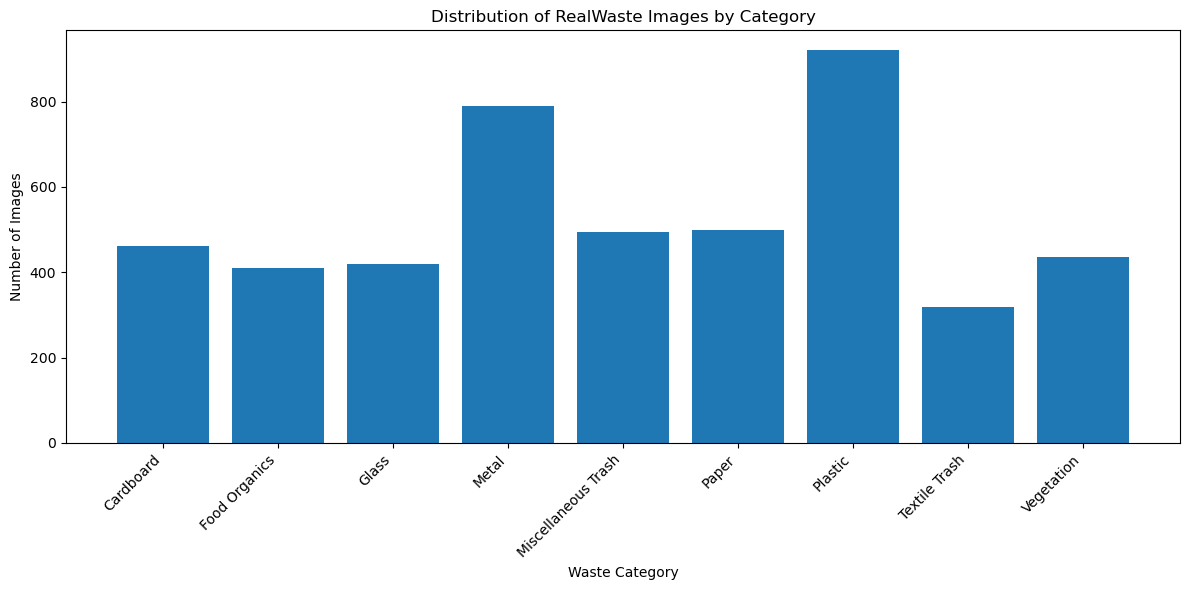


Image characteristics:
        width  height
count  4752.0  4752.0
mean    524.0   524.0
std       0.0     0.0
min     524.0   524.0
25%     524.0   524.0
50%     524.0   524.0
75%     524.0   524.0
max     524.0   524.0

Image modes:
mode
RGB    4752
Name: count, dtype: int64

Most common resolutions:
width  height
524    524       4752
dtype: int64


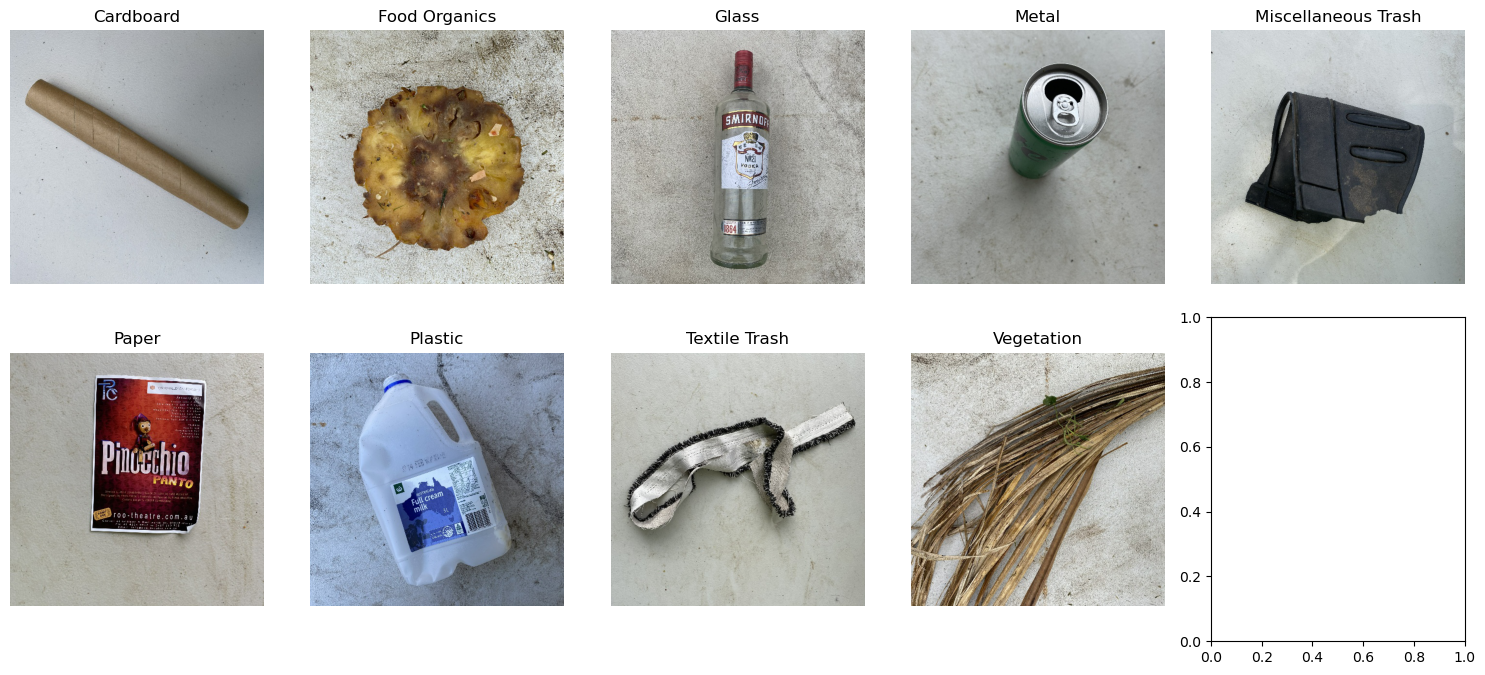

In [3]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)


# loading the RealWaste dataset
data_dir = "RealWaste"  # relative path: works locally, in Colab and after cloning the repo

# Exploring dataset structure
categories = sorted([
    folder for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, folder))
])

print("Number of waste categories:", len(categories))
print("\nWaste categories:")
for category in categories:
    print("-", category)


# check Distribution of waste categories
category_counts = {}

for category in categories:
    category_path = os.path.join(data_dir, category)
    images = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    category_counts[category] = len(images)

print("\nImages per category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


# Plot category distribution
plt.figure(figsize=(12, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xticks(rotation=45, ha="right")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.title("Distribution of RealWaste Images by Category")
plt.tight_layout()
plt.show()


# Examine image characteristics
image_info = []

for category in categories:
    category_path = os.path.join(data_dir, category)

    for filename in os.listdir(category_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            filepath = os.path.join(category_path, filename)

            try:
                with Image.open(filepath) as img:
                    image_info.append({
                        "category": category,
                        "filename": filename,
                        "width": img.width,
                        "height": img.height,
                        "mode": img.mode
                    })
            except Exception as e:
                print(f"Could not read {filepath}: {e}")


# Convert image information to DataFrame
image_df = pd.DataFrame(image_info)

print("\nImage characteristics:")
print(image_df[["width", "height", "mode"]].describe())

print("\nImage modes:")
print(image_df["mode"].value_counts())

print("\nMost common resolutions:")
print(
    image_df.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)


# Display sample images from different categories
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, category in enumerate(categories[:10]):
    category_path = os.path.join(data_dir, category)

    image_files = [
        f for f in os.listdir(category_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        filepath = os.path.join(category_path, image_files[0])

        img = Image.open(filepath)

        axes[i].imshow(img)
        axes[i].set_title(category)
        axes[i].axis("off")

plt.tight_layout()
plt.show()

### 1.2 Explore Text Datasets

In [4]:
import glob, shutil

targets = {"waste_descriptions.csv": "waste_descriptions*.csv*",
           "waste_policy_documents.json": "waste_policy_documents*.json*"}
search_roots = [os.path.expanduser("~/Desktop"), os.path.expanduser("~/Downloads")]

for correct_name, pattern in targets.items():
    if os.path.exists(correct_name):
        print(f"OK: {correct_name} already here")
        continue
    matches = [m for root in search_roots
               for m in glob.glob(os.path.join(root, "**", pattern), recursive=True)]
    if matches:
        shutil.copy(matches[0], correct_name)
        print(f"Copied {matches[0]} -> {os.path.abspath(correct_name)}")
    else:
        print(f"NOT FOUND: {correct_name}. Download it from your GitHub repo into {os.getcwd()}")

OK: waste_descriptions.csv already here
OK: waste_policy_documents.json already here


Dataset shape: (5000, 5)

Column names:
['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']

First 5 rows:


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB

Missing values:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64

Number of duplicate rows: 7

Dataset summary:


,description,category,disposal_instruction,common_confusion,material_composition
count,5000,5000,5000,2496,5000
unique,4939,9,44,9,9
top,glass tabletop,Vegetation,Rinse container before recycling.,Invasive species may require special disposal....,Plant matter composed primarily of cellulose a...
freq,3,600,239,315,600


Total words: 25241
Unique words (vocabulary size): 309

Most common words:
with: 727
sized: 534
glass: 424
empty: 348
bottle: 342
food: 316
paper: 316
box: 313
residue: 309
plastic: 280
metal: 270
brand: 247
dry: 211
new: 196
soiled: 189
crumpled: 189
medium: 187
orange: 186
stained: 185
intact: 184

Waste category distribution:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


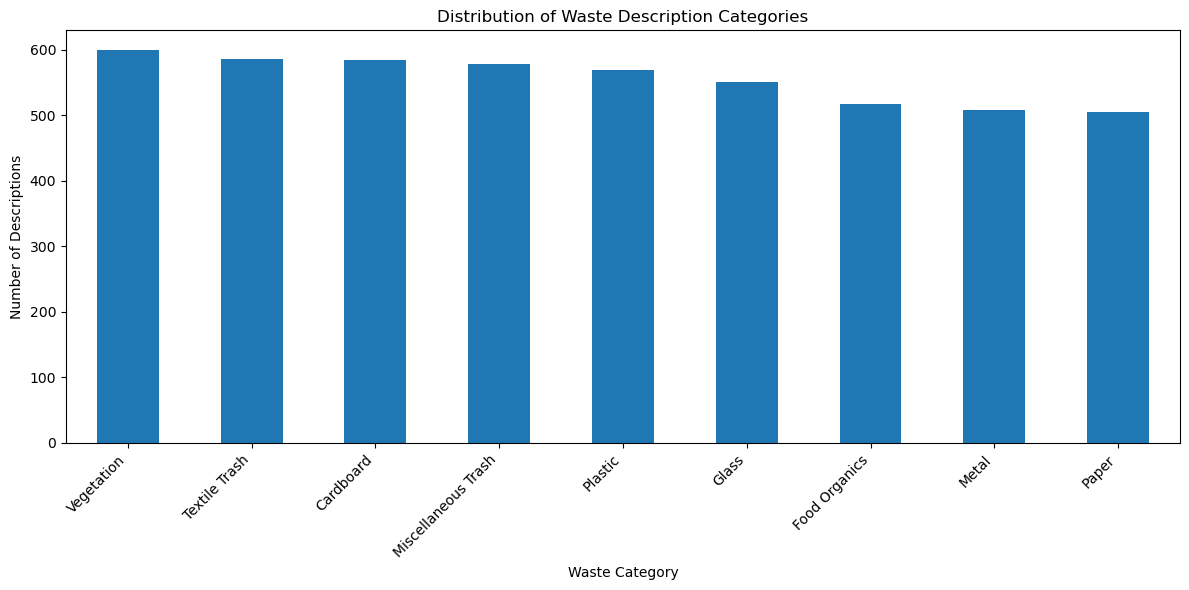

In [5]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
# Loading  dataset
df = pd.read_csv("waste_descriptions.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Summary statistics
print("\nDataset summary:")
display(df.describe(include="all"))

# Combine all descriptions into one text string
text_column = "description"
category_column = "category"

all_text = " ".join(df[text_column].dropna().astype(str))

# Convert to lowercase and extract words
words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

# Analyze vocabulary and structure
vocabulary = set(words)

print("Total words:", len(words))
print("Unique words (vocabulary size):", len(vocabulary))

# Most common words
word_counts = Counter(words)

print("\nMost common words:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

# - distribution of categories
category_counts = df[category_column].value_counts()

print("\nWaste category distribution:")
print(category_counts)

plt.figure(figsize=(12, 6))
category_counts.plot(kind="bar")
plt.xlabel("Waste Category")
plt.ylabel("Number of Descriptions")
plt.title("Distribution of Waste Description Categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Dataset shape: (14, 6)

Columns:
['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']

First 5 documents:


,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     object
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     object
 4   document_text       14 non-null     object
 5   jurisdiction        14 non-null     object
dtypes: int64(1), object(5)
memory usage: 804.0+ bytes

Missing values:
policy_id             0
policy_type           0
categories_covered    0
effective_date        0
document_text         0
jurisdiction          0
dtype: int64

Policy types:
policy_type
Textile Trash Recycling Guidelines          1
Glass Recycling Guidelines                  1
Food Organics Recycling Guidelines          1
Plastic Recycling Guidelines                1
Vegetation Recycling Guidelines             1
Cardbo

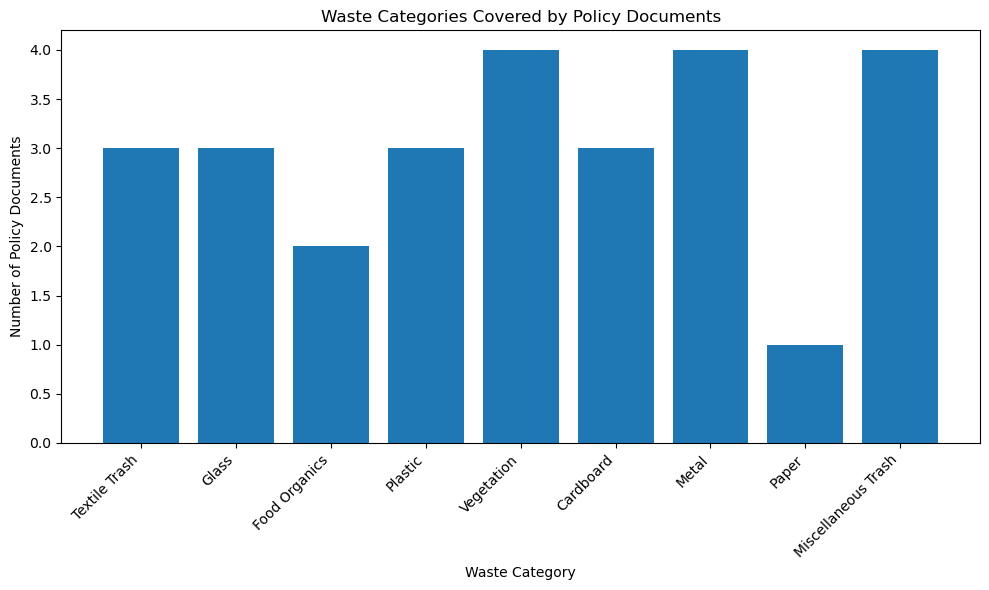

Total words: 1211
Vocabulary size: 325

Most common words:
and: 63
guidelines: 34
items: 33
recycling: 29
non: 23
containers: 23
clean: 21
glass: 21
plastic: 20
packaging: 19
cardboard: 18
acceptable: 16
or: 16
food: 16
collection: 15
paper: 15
bins: 14
metal: 14
cans: 14
in: 12
bags: 12
materials: 12
place: 11
with: 10
waste: 10

Document length statistics:
count     14.000000
mean     101.785714
std       15.115853
min       86.000000
25%       94.250000
50%       99.000000
75%      102.000000
max      146.000000
Name: word_count, dtype: float64
Policy ID: 1
Policy Type: Textile Trash Recycling Guidelines
Categories: Textile Trash
Effective Date: 2023-11-04
Jurisdiction: Metro City

Document:
TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled item

In [6]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Loading the waste policy documents
with open("waste_policy_documents.json", "r", encoding="utf-8") as file:
    policy_data = json.load(file)

# Convert JSON records to a DataFrame
policy_df = pd.DataFrame(policy_data)

print("Dataset shape:", policy_df.shape)

print("\nColumns:")
print(policy_df.columns.tolist())

print("\nFirst 5 documents:")
display(policy_df.head())

# Check basic information
print("\nDataset information:")
policy_df.info()

print("\nMissing values:")
print(policy_df.isnull().sum())

print("\nPolicy types:")
print(policy_df["policy_type"].value_counts())

print("\nJurisdictions:")
print(policy_df["jurisdiction"].value_counts())

# Flatten categories covered by all policies
all_categories = []

for categories in policy_df["categories_covered"]:
    all_categories.extend(categories)

category_counts = Counter(all_categories)

print("Waste categories covered:")
for category, count in category_counts.most_common():
    print(f"{category}: {count}")

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.keys(),
    category_counts.values()
)

plt.xlabel("Waste Category")
plt.ylabel("Number of Policy Documents")
plt.title("Waste Categories Covered by Policy Documents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Combine all policy documents
all_text = " ".join(
    policy_df["document_text"].astype(str)
)

# Convert to lowercase and extract words
words = re.findall(
    r"\b[a-zA-Z]+\b",
    all_text.lower()
)

vocabulary = set(words)

print("Total words:", len(words))
print("Vocabulary size:", len(vocabulary))

print("\nMost common words:")
word_counts = Counter(words)

for word, count in word_counts.most_common(25):
    print(f"{word}: {count}")

# Number of words in each policy document
policy_df["word_count"] = policy_df["document_text"].apply(
    lambda x: len(str(x).split())
)

print("\nDocument length statistics:")
print(policy_df["word_count"].describe())

for _, row in policy_df.iterrows():
    print("=" * 80)
    print(f"Policy ID: {row['policy_id']}")
    print(f"Policy Type: {row['policy_type']}")
    print(f"Categories: {', '.join(row['categories_covered'])}")
    print(f"Effective Date: {row['effective_date']}")
    print(f"Jurisdiction: {row['jurisdiction']}")
    print("\nDocument:")
    print(row["document_text"][:500])
    print()

### 1.3 Create Data Pipelines

In [7]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [8]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# Your code here
# Load the waste descriptions dataset
waste_text = pd.read_csv("waste_descriptions.csv")

# Inspect the columns
print(waste_text.head())
print(waste_text.columns)

# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Clean text
waste_text["clean_text"] = waste_text["description"].apply(clean_text)

print(waste_text[["description", "clean_text"]].head())

# Features and target
X = waste_text["clean_text"]
y = waste_text["category"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)


                                         description       category  \
0                           soiled silver tablecloth  Textile Trash   
1                        folded glass bottle leaking          Glass   
2  large Supermarket vegetable waste with food re...  Food Organics   
3                         intact floral carpet piece  Textile Trash   
4                  empty fun-sized purple apple core  Food Organics   

                                disposal_instruction  \
0  Look for textile recycling programs in your area.   
1     Remove caps, lids, and corks before recycling.   
2   If no compost available, place in general waste.   
3  Look for textile recycling programs in your area.   
4           Keep separate from recyclable materials.   

                                    common_confusion  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3           

In [9]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

from sentence_transformers import SentenceTransformer

# Load the policy documents
with open("waste_policy_documents.json", "r", encoding="utf-8") as f:
    policy_documents = json.load(f)

print(f"Number of documents: {len(policy_documents)}")

# - Document preprocessing
# Preview the first document
print(policy_documents[0])

def clean_document(text):
    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Create clean text while preserving the original documents
for document in policy_documents:
    document["clean_text"] = clean_document(document["document_text"])

print(policy_documents[0]["clean_text"])

# Load the embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Extract the cleaned text
documents_text = [
    document["clean_text"]
    for document in policy_documents
]

# Create embeddings
document_embeddings = embedding_model.encode(
    documents_text,
    show_progress_bar=True
)

print("Embedding shape:", document_embeddings.shape)

Number of documents: 14
{'policy_id': 1, 'policy_type': 'Textile Trash Recycling Guidelines', 'categories_covered': ['Textile Trash'], 'effective_date': '2023-11-04', 'document_text': 'TEXTILE RECYCLING GUIDELINES\n\nAcceptable Items:\n- Clean clothing (all conditions)\n- Towels, sheets, and linens\n- Fabric scraps\n- Curtains and cloth napkins\n- Handbags and backpacks made of fabric\n- Soft toys and stuffed animals\n\nNon-Acceptable Items:\n- Wet or moldy textiles\n- Heavily soiled items\n- Carpets and rugs\n- Footwear\n- Items with significant non-textile parts\n\nCollection Method:\nPlace items in dedicated textile recycling bins or donate to local thrift stores.\n\nPreparation Instructions:\n- Ensure all items are clean and dry\n- Remove non-textile components when possible\n- Bag similar items together\n\nBenefits:\nTextile recycling conserves resources and reduces landfill waste.', 'jurisdiction': 'Metro City'}
textile recycling guidelines acceptable items: - clean clothing (all

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (14, 384)


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

**Approach for 2.1**

The pipeline from 1.3 is reused (same `data_dir`, image size, batch size, seed and 80/20 file split), with three corrections before training:

1. **Leakage between validation and test.** `image_dataset_from_directory(shuffle=True)` reshuffles the hold-out set on every pass, so `take()` and `skip()` can each draw from a different ordering. Images near the split boundary can end up in both validation and test, and the test split is not stratified. The 20% hold-out is therefore loaded once into memory and split 50/50 with stratification, which also gives a fixed test order so predictions line up with labels for the confusion matrix.
2. **Stale training order.** `train_ds.cache()` freezes the order of the first epoch. Images are now cached first and reshuffled every epoch.
3. **Memory.** Images are cached as `uint8` (about 0.6 GB) instead of `float32` (about 2.3 GB).

Model-specific preprocessing (augmentation and scaling to [-1, 1] for MobileNetV2) is built into the model in 2.2, so the saved model accepts raw 0 to 255 RGB images. This keeps inference in Part 5 simple and guarantees identical preprocessing at training and prediction time. Class weights are computed because the classes are imbalanced (Plastic 921 images vs Textile Trash 318).

Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Train images:      3802
Validation images: 475
Test images:       475


,train,val,test,class_weight
Cardboard,387,37,37,1.09
Food Organics,327,42,42,1.29
Glass,342,39,39,1.24
Metal,617,87,86,0.68
Miscellaneous Trash,403,46,46,1.05
Paper,381,60,59,1.11
Plastic,742,89,90,0.57
Textile Trash,243,37,38,1.74
Vegetation,360,38,38,1.17


Batch shape: (32, 224, 224, 3) | Label shape: (32, 9)
Raw pixel range: 0.0 to 255.0
Scaled pixel range: -1.0 to 1.0


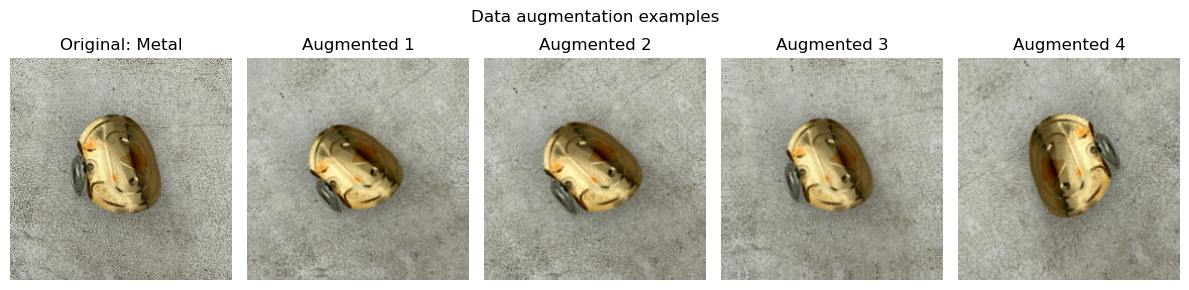

In [10]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)


def load_split(subset):
    """Re-create a split from 1.3 with identical settings (same seed => same files)."""
    return tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset=subset,
        seed=42,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        label_mode="categorical",
        shuffle=True,
    )


def to_uint8(x, y):
    # Resized pixels are float32 in [0, 255]; storing as uint8 cuts cache memory by 4x
    return tf.cast(tf.round(x), tf.uint8), y


def to_float(x, y):
    return tf.cast(x, tf.float32), y


train_raw = load_split("training")
holdout_raw = load_split("validation")
class_names = train_raw.class_names
num_classes = len(class_names)

# ---- Training set: cache once, reshuffle every epoch, then batch ----
train_ds = (
    train_raw.unbatch()
    .map(to_uint8, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000, seed=42, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .map(to_float, num_parallel_calls=AUTOTUNE)
    # unbatch() hides the dataset size; restoring it avoids a "ran out of data" warning in fit()
    .apply(tf.data.experimental.assert_cardinality(
        int(np.ceil(len(train_raw.file_paths) / BATCH_SIZE))))
    .prefetch(AUTOTUNE)
)

# ---- Hold-out set: load once, then stratified 50/50 split into validation and test ----
x_hold, y_hold = [], []
for xb, yb in holdout_raw:
    xb, yb = to_uint8(xb, yb)
    x_hold.append(xb.numpy())
    y_hold.append(yb.numpy())
x_hold = np.concatenate(x_hold)
y_hold = np.concatenate(y_hold)

# Names end in _img so they do not overwrite the text-model variables (X_test, y_test) from 1.3
x_val_img, x_test_img, y_val_img, y_test_img = train_test_split(
    x_hold, y_hold, test_size=0.5, stratify=y_hold.argmax(axis=1), random_state=42
)


def make_eval_ds(x, y):
    """Fixed-order (unshuffled) dataset so predictions align with labels."""
    return (
        tf.data.Dataset.from_tensor_slices((x, y))
        .batch(BATCH_SIZE)
        .map(to_float, num_parallel_calls=AUTOTUNE)
        .prefetch(AUTOTUNE)
    )


validation_ds = make_eval_ds(x_val_img, y_val_img)
test_dataset = make_eval_ds(x_test_img, y_test_img)

print(f"Train images:      {len(train_raw.file_paths)}")
print(f"Validation images: {len(x_val_img)}")
print(f"Test images:       {len(x_test_img)}")

# ---- Class weights to counter class imbalance (computed from training labels only) ----
train_labels = np.array(
    [class_names.index(pathlib.Path(p).parent.name) for p in train_raw.file_paths]
)
weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=train_labels)
class_weight = dict(enumerate(weights))

split_summary = pd.DataFrame({
    "train": np.bincount(train_labels, minlength=num_classes),
    "val": np.bincount(y_val_img.argmax(1), minlength=num_classes),
    "test": np.bincount(y_test_img.argmax(1), minlength=num_classes),
    "class_weight": np.round(weights, 2),
}, index=class_names)
display(split_summary)

# ---- Augmentation (active only during training; applied inside the model) ----
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# MobileNetV2 expects inputs in [-1, 1]; this layer is equivalent to
# tf.keras.applications.mobilenet_v2.preprocess_input but is saved with the model
preprocess = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="mobilenetv2_preprocess")

# ---- Sanity checks ----
images, labels = next(iter(train_ds))
print("Batch shape:", images.shape, "| Label shape:", labels.shape)
print("Raw pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))
scaled = preprocess(images)
print("Scaled pixel range:", float(tf.reduce_min(scaled)), "to", float(tf.reduce_max(scaled)))

# Visualise augmentation on one training image
plt.figure(figsize=(12, 3))
sample_class = class_names[int(labels[0].numpy().argmax())]
for i in range(5):
    img = images[0] if i == 0 else data_augmentation(images[:1], training=True)[0]
    plt.subplot(1, 5, i + 1)
    plt.imshow(np.clip(img.numpy(), 0, 255).astype("uint8"))
    plt.title(f"Original: {sample_class}" if i == 0 else f"Augmented {i}")
    plt.axis("off")
plt.suptitle("Data augmentation examples")
plt.tight_layout()
plt.show()


### 2.2 Implement CNN Model with Transfer Learning

**Model choice: MobileNetV2 with transfer learning**

* MobileNetV2 is pre-trained on ImageNet, so it already detects edges, textures and shapes that transfer well to waste materials, which matters with only about 3,800 training images.
* It is lightweight (about 2.3M parameters in the base), so it trains in reasonable time on a CPU and suits a resident-facing app that may run on mobile devices.
* EfficientNetB0 is a reasonable alternative with slightly higher accuracy but slower training.

The base is frozen at first so only the new head is trained; the randomly initialised head would otherwise send large gradients into the pre-trained weights and damage them. The head is GlobalAveragePooling, Dropout and a softmax Dense layer with 9 outputs and L2 regularisation.

Loss is categorical cross-entropy (labels are one-hot) with label smoothing 0.1, which reduces over-confidence on visually similar classes such as Paper and Cardboard. Metrics are accuracy and top-3 accuracy (useful for an assistant that could offer residents alternatives).

In [11]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

from tensorflow.keras import regularizers


def build_cnn(dropout_rate=0.3, l2_strength=1e-4, learning_rate=1e-3):
    """MobileNetV2 transfer-learning classifier for the 9 RealWaste categories."""
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE, include_top=False, weights="imagenet"
    )
    base_model.trainable = False  # feature extraction stage

    inputs = tf.keras.Input(shape=IMG_SHAPE, name="image")
    x = data_augmentation(inputs)          # only active when training=True
    x = preprocess(x)                      # [0, 255] -> [-1, 1]
    x = base_model(x, training=False)      # keep BatchNorm in inference mode
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=regularizers.l2(l2_strength),
        name="waste_class",
    )(x)

    model = tf.keras.Model(inputs, outputs, name="waste_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
    )
    return model, base_model


cnn_model, base_model = build_cnn()
cnn_model.summary()
print(f"Layers in base model: {len(base_model.layers)}")


Model: "waste_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_preprocess (Rescaling)   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)         │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ waste_class (Dense)                  │ (None, 9)                   │          11,529 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Layers in base model: 154


### 2.3 Train and Evaluate the Model

**Training setup**

* Batch size 32 (from 1.3) and up to 20 epochs, with early stopping so the actual number of epochs is chosen by validation loss.
* Regularisation against overfitting: data augmentation, dropout, L2 weight decay, label smoothing, and early stopping that restores the best weights.
* `ReduceLROnPlateau` halves the learning rate when validation loss stalls; `ModelCheckpoint` keeps the best model on disk.
* Class weights from 2.1 make errors on small classes (Textile Trash) count as much as errors on large ones (Plastic).

Epoch 1/20


C:\Users\User\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


119/119 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.4845 - loss: 1.6307 - top3_acc: 0.7767 - val_accuracy: 0.6358 - val_loss: 1.2604 - val_top3_acc: 0.9305 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.6662 - loss: 1.1979 - top3_acc: 0.9150 - val_accuracy: 0.6947 - val_loss: 1.1342 - val_top3_acc: 0.9432 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 118s 989ms/step - accuracy: 0.7107 - loss: 1.1258 - top3_acc: 0.9300 - val_accuracy: 0.7221 - val_loss: 1.0804 - val_top3_acc: 0.9495 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 119s 998ms/step - accuracy: 0.7451 - loss: 1.0546 - top3_acc: 0.9461 - val_accuracy: 0.7537 - val_loss: 1.0546 - val_top3_acc: 0.9579 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 118s 992ms/step - accuracy: 0.7604 - loss: 1.0218 - top3_acc: 0.9532 - val_accuracy: 0.7642 - val_loss: 1.0488 - val_top3_acc: 0.9621 - learning_rate: 0.0010
Epoch 6/20
119/119 ━━━━━━━━

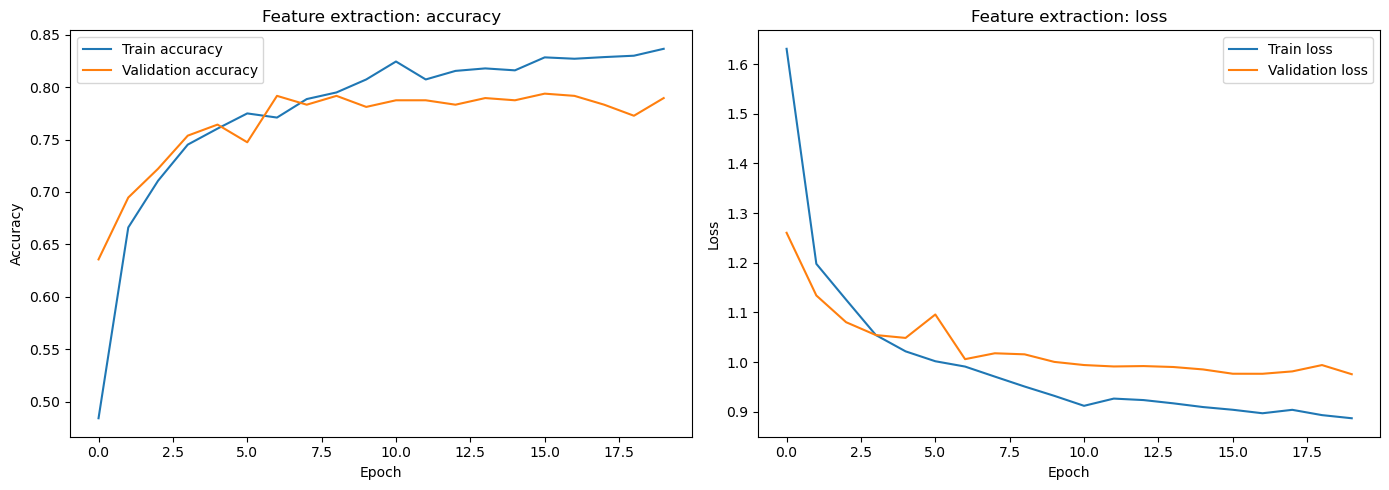

Best epoch: 20
Train accuracy at best epoch:      0.8364
Validation accuracy at best epoch: 0.7895


In [12]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics


def get_callbacks(checkpoint_path, patience=4):
    """Fresh callback objects for each training run."""
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0
        ),
    ]


INITIAL_EPOCHS = 20

history = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight,
    callbacks=get_callbacks("cnn_feature_extraction.keras"),
    verbose=1,
)


def plot_history(histories, fine_tune_start=None, title="Training history"):
    """Plot accuracy and loss for one or more History objects joined end to end."""
    hist = {}
    for h in histories:
        for k, v in h.history.items():
            hist.setdefault(k, []).extend(v)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(hist[metric], label=f"Train {metric}")
        ax.plot(hist[f"val_{metric}"], label=f"Validation {metric}")
        if fine_tune_start is not None:
            ax.axvline(fine_tune_start - 1, color="grey", linestyle="--", label="Start fine-tuning")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f"{title}: {metric}")
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_history([history], title="Feature extraction")

best_epoch = int(np.argmin(history.history["val_loss"]))
print(f"Best epoch: {best_epoch + 1}")
print(f"Train accuracy at best epoch:      {history.history['accuracy'][best_epoch]:.4f}")
print(f"Validation accuracy at best epoch: {history.history['val_accuracy'][best_epoch]:.4f}")


Feature extraction (test) accuracy:       0.7705
Feature extraction (test) top-3 accuracy: 0.9684

                     precision    recall  f1-score   support

          Cardboard      0.765     0.703     0.732        37
      Food Organics      0.971     0.786     0.868        42
              Glass      0.596     0.795     0.681        39
              Metal      0.815     0.767     0.790        86
Miscellaneous Trash      0.579     0.478     0.524        46
              Paper      0.737     0.949     0.830        59
            Plastic      0.787     0.700     0.741        90
      Textile Trash      0.861     0.816     0.838        38
         Vegetation      0.864     1.000     0.927        38

           accuracy                          0.771       475
          macro avg      0.775     0.777     0.770       475
       weighted avg      0.777     0.771     0.768       475



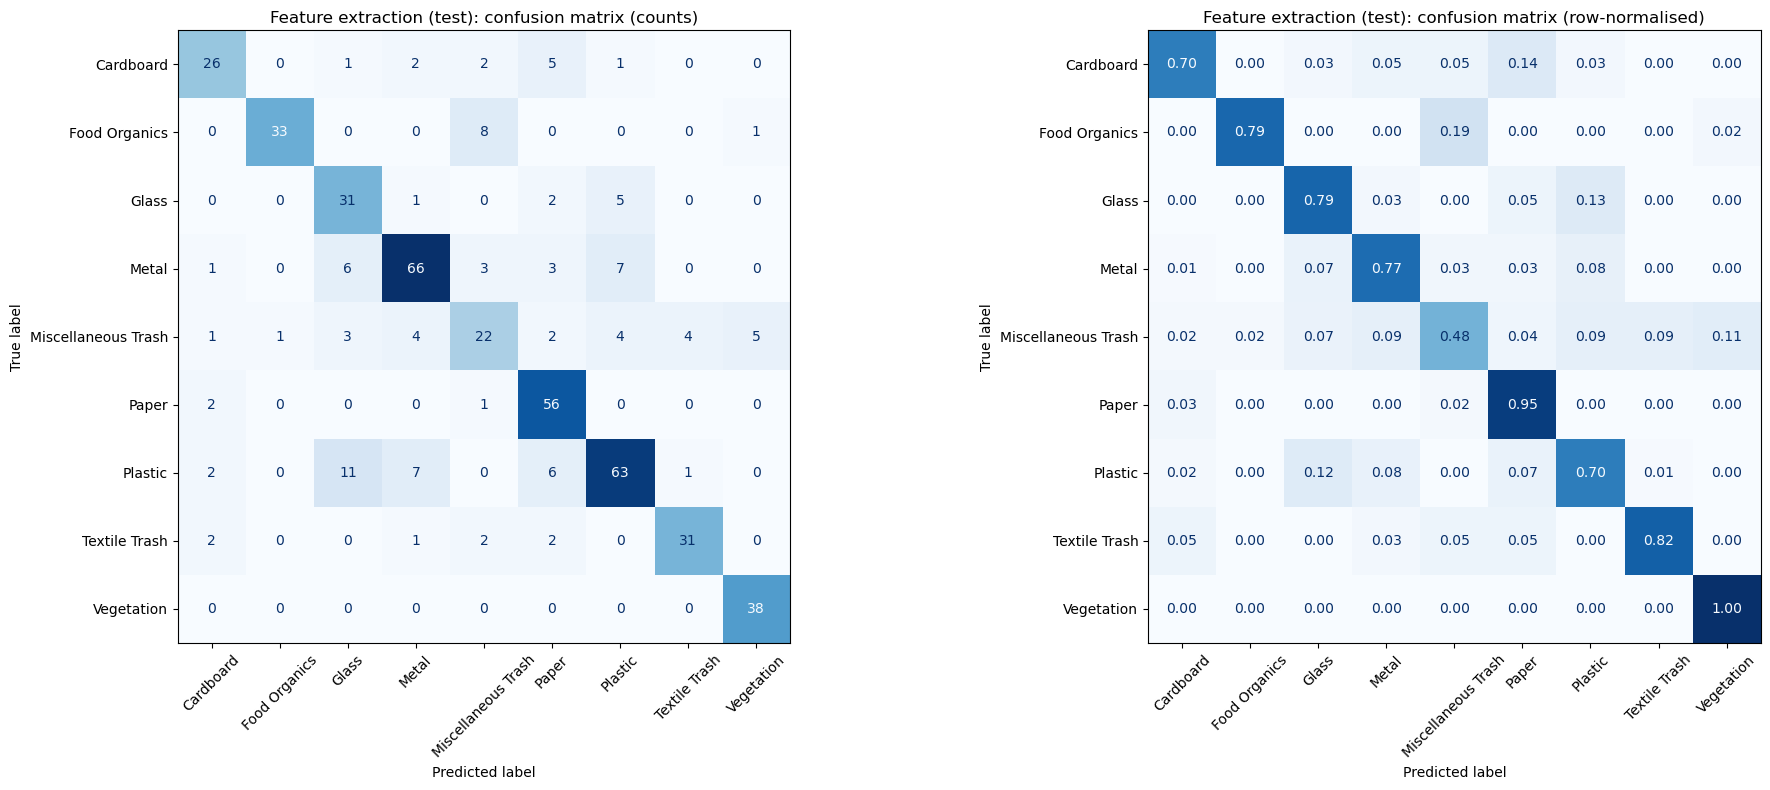

Most common confusions (true -> predicted):
  Plastic              -> Glass                11
  Food Organics        -> Miscellaneous Trash  8
  Plastic              -> Metal                7
  Metal                -> Plastic              7
  Plastic              -> Paper                6
  Metal                -> Glass                6
  Miscellaneous Trash  -> Vegetation           5
  Glass                -> Plastic              5

Mean confidence when correct: 0.771
Mean confidence when wrong:   0.512


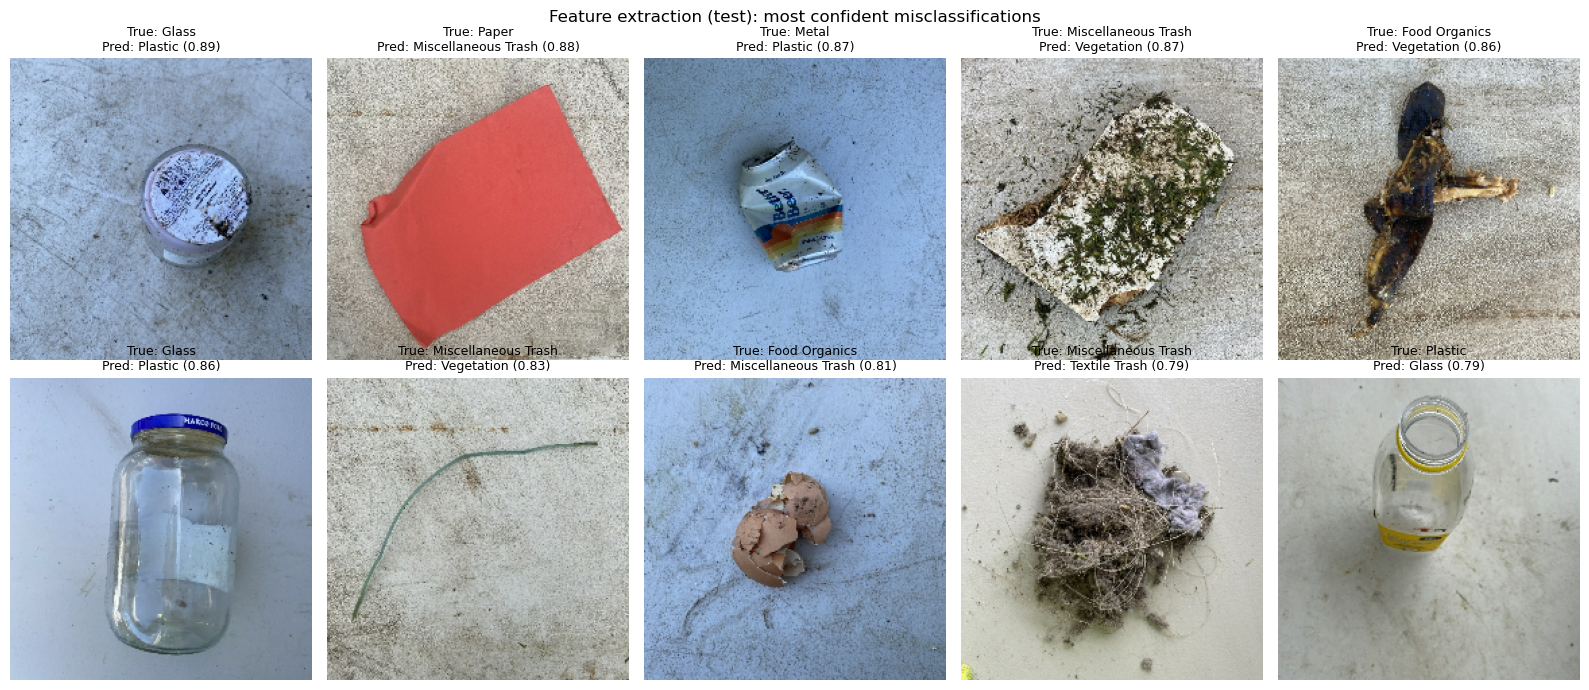

In [13]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)


def evaluate_cnn(model, ds, y_true_onehot, x_images, title="Test set"):
    """Accuracy, per-class report, confusion matrix and error analysis on a fixed-order dataset."""
    probs = model.predict(ds, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = y_true_onehot.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    top3 = np.mean([t in np.argsort(p)[-3:] for t, p in zip(y_true, probs)])
    print(f"{title} accuracy:       {acc:.4f}")
    print(f"{title} top-3 accuracy: {top3:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

    # Confusion matrix: counts and row-normalised (recall per class)
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{title}: confusion matrix (counts)")
    ConfusionMatrixDisplay(cm / cm.sum(axis=1, keepdims=True), display_labels=class_names).plot(
        ax=axes[1], cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False)
    axes[1].set_title(f"{title}: confusion matrix (row-normalised)")
    plt.tight_layout()
    plt.show()

    # Error pattern 1: most frequent confusions (true -> predicted)
    off_diag = cm.copy()
    np.fill_diagonal(off_diag, 0)
    pairs = [(off_diag[i, j], class_names[i], class_names[j])
             for i in range(num_classes) for j in range(num_classes) if off_diag[i, j] > 0]
    print("Most common confusions (true -> predicted):")
    for count, t, p in sorted(pairs, reverse=True)[:8]:
        print(f"  {t:20s} -> {p:20s} {count}")

    # Error pattern 2: confidence on correct vs wrong predictions
    conf = probs.max(axis=1)
    wrong = y_pred != y_true
    print(f"\nMean confidence when correct: {conf[~wrong].mean():.3f}")
    print(f"Mean confidence when wrong:   {conf[wrong].mean():.3f}" if wrong.any() else "")

    # Error pattern 3: show the most confident mistakes
    wrong_idx = np.where(wrong)[0]
    worst = wrong_idx[np.argsort(-conf[wrong_idx])][:10]
    if len(worst):
        plt.figure(figsize=(16, 7))
        for k, i in enumerate(worst):
            plt.subplot(2, 5, k + 1)
            plt.imshow(x_images[i].astype("uint8"))
            plt.title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]} ({conf[i]:.2f})",
                      fontsize=9)
            plt.axis("off")
        plt.suptitle(f"{title}: most confident misclassifications")
        plt.tight_layout()
        plt.show()

    return {"accuracy": acc, "top3": top3, "y_pred": y_pred, "probs": probs, "cm": cm}


results_fe = evaluate_cnn(cnn_model, test_dataset, y_test_img, x_test_img,
                          title="Feature extraction (test)")


**Error analysis (update after running with your own numbers)**

Typical patterns on RealWaste with a frozen base:

* **Paper vs Cardboard**: similar colour and fibre texture; flat, printed cardboard is often called Paper.
* **Plastic vs Glass vs Metal**: transparent or shiny containers share reflections and shapes (bottles, cans).
* **Miscellaneous Trash**: the most heterogeneous class, so it absorbs errors from many others and has the lowest precision.
* **Food Organics vs Vegetation**: both are organic, green or brown, with irregular shapes.

Mistakes made with high confidence point to genuinely ambiguous images (mixed-material items, cluttered backgrounds) rather than an under-trained model. Fine-tuning in 2.4 targets these fine-grained texture differences.

### 2.4 Fine-tune the Model

**Fine-tuning strategy**

* **Unfreeze the top of MobileNetV2** (layers from index 100 onwards). Early layers learn generic edges and colours, which transfer as they are; later layers learn object-specific features that benefit from adapting to waste textures.
* **BatchNormalization layers stay frozen** and the base is called with `training=False`, so the running statistics learned on ImageNet are not overwritten by small batches.
* **Learning rate lowered 100x (1e-3 to 1e-5)**, so the pre-trained weights are nudged rather than overwritten.
* **Regularisation kept**: augmentation, dropout 0.3, L2, label smoothing and early stopping all stay active, because unfreezing adds capacity and raises the risk of overfitting.
* Training continues from the epoch where feature extraction stopped so the curves join up.

Trainable layers in base: 22 / 154
Trainable parameters in model: 1,619,593
Epoch 21/28


C:\Users\User\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


119/119 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8364 - loss: 0.8944 - top3_acc: 0.9784 - val_accuracy: 0.7811 - val_loss: 0.9739 - val_top3_acc: 0.9663 - learning_rate: 1.0000e-05
Epoch 22/28
119/119 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8469 - loss: 0.8640 - top3_acc: 0.9805 - val_accuracy: 0.7874 - val_loss: 0.9586 - val_top3_acc: 0.9705 - learning_rate: 1.0000e-05
Epoch 23/28
119/119 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8714 - loss: 0.8290 - top3_acc: 0.9834 - val_accuracy: 0.8042 - val_loss: 0.9432 - val_top3_acc: 0.9747 - learning_rate: 1.0000e-05
Epoch 24/28
119/119 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.8711 - loss: 0.8291 - top3_acc: 0.9829 - val_accuracy: 0.8126 - val_loss: 0.9316 - val_top3_acc: 0.9705 - learning_rate: 1.0000e-05
Epoch 25/28
119/119 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8777 - loss: 0.8144 - top3_acc: 0.9866 - val_accuracy: 0.8274 - val_loss: 0.9294 - val_top3_acc: 0.9726 - learning_rate: 1.0000e-05
Epoch 26/28


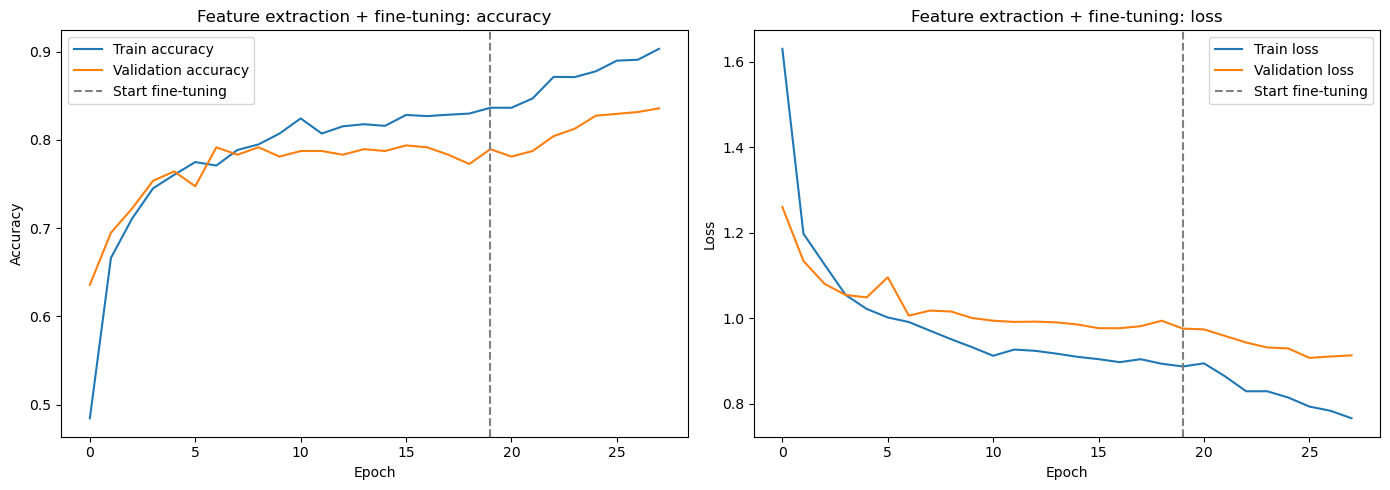

Fine-tuned (test) accuracy:       0.8126
Fine-tuned (test) top-3 accuracy: 0.9768

                     precision    recall  f1-score   support

          Cardboard      0.833     0.811     0.822        37
      Food Organics      1.000     0.786     0.880        42
              Glass      0.667     0.769     0.714        39
              Metal      0.815     0.872     0.843        86
Miscellaneous Trash      0.596     0.739     0.660        46
              Paper      0.844     0.915     0.878        59
            Plastic      0.861     0.689     0.765        90
      Textile Trash      0.909     0.789     0.845        38
         Vegetation      0.884     1.000     0.938        38

           accuracy                          0.813       475
          macro avg      0.823     0.819     0.816       475
       weighted avg      0.825     0.813     0.814       475



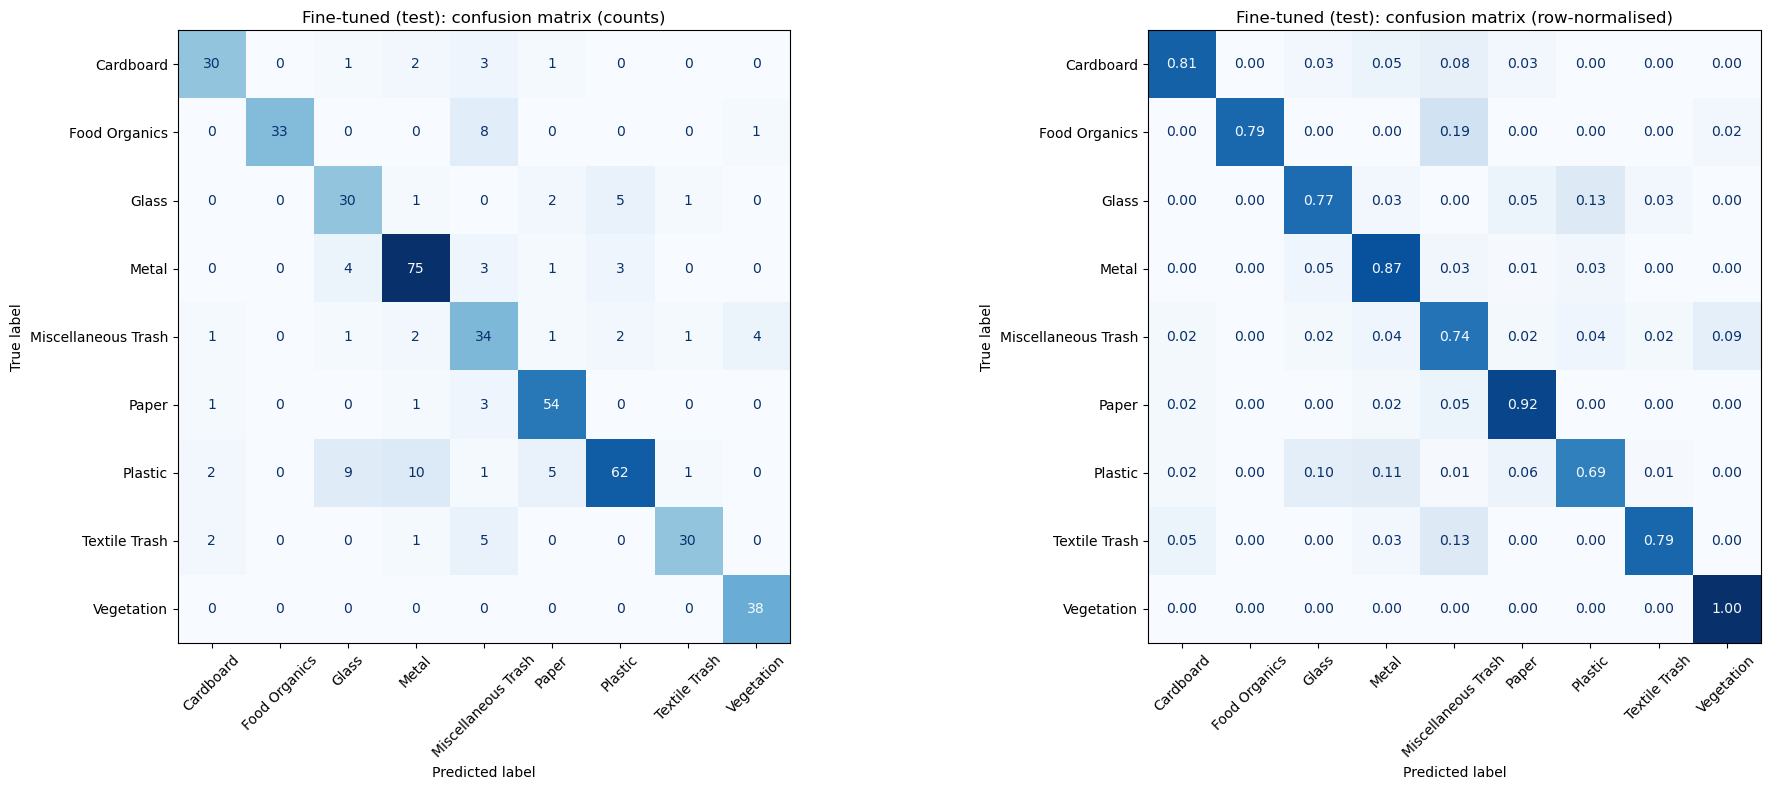

Most common confusions (true -> predicted):
  Plastic              -> Metal                10
  Plastic              -> Glass                9
  Food Organics        -> Miscellaneous Trash  8
  Textile Trash        -> Miscellaneous Trash  5
  Plastic              -> Paper                5
  Glass                -> Plastic              5
  Miscellaneous Trash  -> Vegetation           4
  Metal                -> Glass                4

Mean confidence when correct: 0.788
Mean confidence when wrong:   0.525


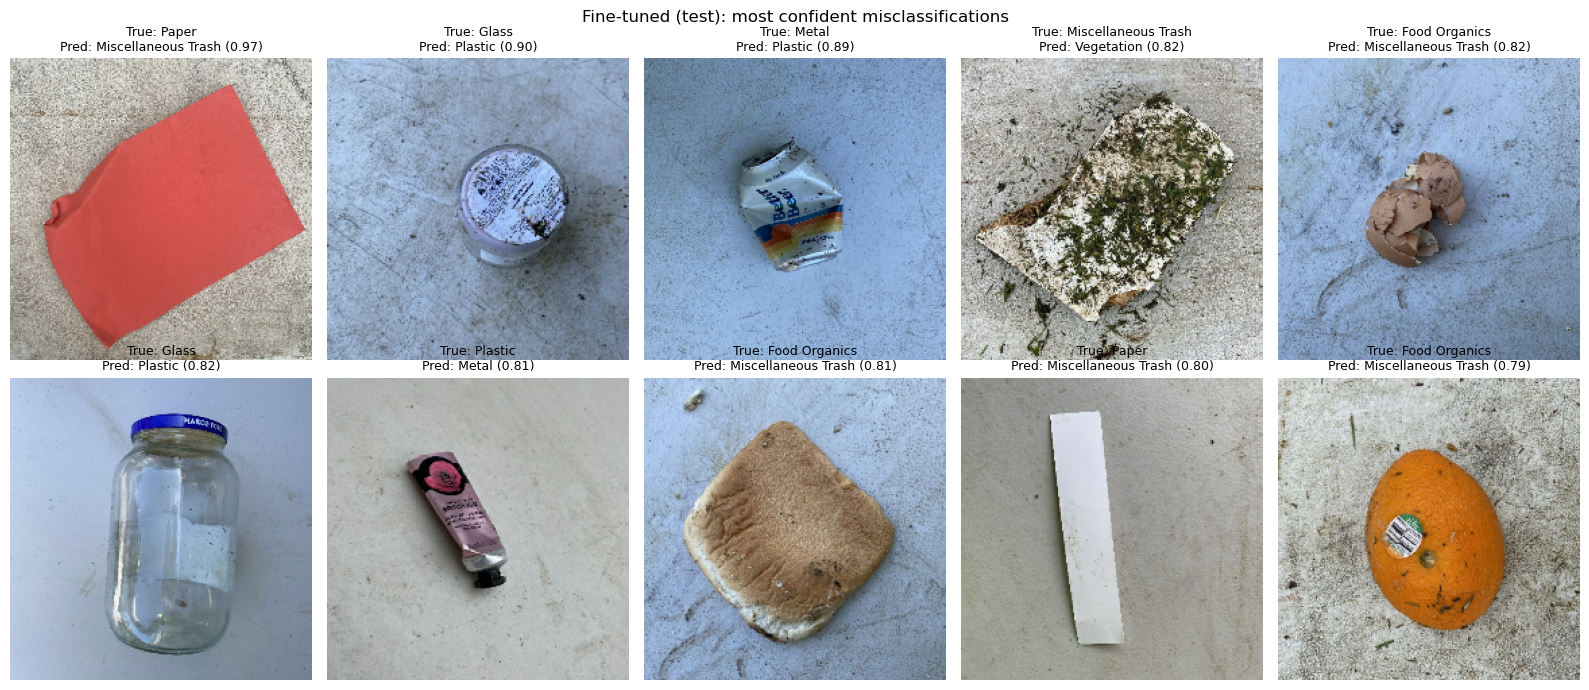

,Feature extraction,Fine-tuned,Change
Test accuracy,0.7705,0.8126,0.0421
Test top-3 accuracy,0.9684,0.9768,0.0084


,Recall before,Recall after,Change
Miscellaneous Trash,0.478,0.739,0.261
Cardboard,0.703,0.811,0.108
Metal,0.767,0.872,0.105
Food Organics,0.786,0.786,0.000
Vegetation,1.000,1.000,0.000
Plastic,0.700,0.689,-0.011
Glass,0.795,0.769,-0.026
Textile Trash,0.816,0.789,-0.027
Paper,0.949,0.915,-0.034


Saved final CNN to waste_cnn_final.keras


In [14]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

FINE_TUNE_AT = 120        # unfreeze layers from this index onwards
FINE_TUNE_LR = 1e-5       # 100x lower than the feature-extraction learning rate
FINE_TUNE_EPOCHS = 8

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(np.prod(w.shape)) for w in cnn_model.trainable_weights)
print(f"Trainable layers in base: {sum(l.trainable for l in base_model.layers)} / {len(base_model.layers)}")
print(f"Trainable parameters in model: {trainable_count:,}")

# Recompile so the new trainable flags and learning rate take effect
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
)

start_epoch = len(history.history["loss"])
history_ft = cnn_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=start_epoch + FINE_TUNE_EPOCHS,
    initial_epoch=start_epoch,
    class_weight=class_weight,
    callbacks=get_callbacks("cnn_fine_tuned.keras", patience=5),
    verbose=1,
)

plot_history([history, history_ft], fine_tune_start=start_epoch,
             title="Feature extraction + fine-tuning")

results_ft = evaluate_cnn(cnn_model, test_dataset, y_test_img, x_test_img,
                          title="Fine-tuned (test)")

# ---- Before vs after comparison ----
comparison = pd.DataFrame({
    "Feature extraction": [results_fe["accuracy"], results_fe["top3"]],
    "Fine-tuned": [results_ft["accuracy"], results_ft["top3"]],
}, index=["Test accuracy", "Test top-3 accuracy"]).round(4)
comparison["Change"] = (comparison["Fine-tuned"] - comparison["Feature extraction"]).round(4)
display(comparison)

per_class = pd.DataFrame({
    "Recall before": np.diag(results_fe["cm"]) / results_fe["cm"].sum(axis=1),
    "Recall after": np.diag(results_ft["cm"]) / results_ft["cm"].sum(axis=1),
}, index=class_names).round(3)
per_class["Change"] = (per_class["Recall after"] - per_class["Recall before"]).round(3)
display(per_class.sort_values("Change", ascending=False))

# Keep the better model for the integrated assistant (Part 5)
if results_ft["accuracy"] < results_fe["accuracy"]:
    print("Fine-tuning did not help on the test set; reloading the feature-extraction model.")
    cnn_model = tf.keras.models.load_model("cnn_feature_extraction.keras")

cnn_model.save("waste_cnn_final.keras")
CNN_CLASS_NAMES = class_names
print("Saved final CNN to waste_cnn_final.keras")


**Fine-tuning results (update after running)**

Compare the two confusion matrices and the per-class recall table. Fine-tuning usually gives the largest gains on texture-based confusions (Paper vs Cardboard, Food Organics vs Vegetation). If validation loss rises while training loss keeps falling, the model is overfitting: unfreeze fewer layers (raise `FINE_TUNE_AT` to 120) or raise dropout to 0.4. If accuracy barely moves, unfreeze more layers (`FINE_TUNE_AT = 60`) or try `FINE_TUNE_LR = 3e-5`.

The final model takes raw RGB images resized to 224 x 224 with pixel values 0 to 255; augmentation switches off automatically at inference. Part 5 only needs to load, resize and call `cnn_model.predict`, then map the argmax to `CNN_CLASS_NAMES`.

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

### 3.2 Implement Text Classification Model

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

### 3.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.